# Recitation: Cross-Validation, Prediction Metrics, and Logistic Regression

In this recitation, we will cover some essential concepts in model evaluation and classification modeling. The focus will be on understanding how to properly validate a model, how to interpret prediction metrics, and how logistic regression works.

---

## Topics Covered

### 1. Cross-Validation Techniques
- Train/Validation/Test Split
- K-Fold Cross-Validation
- Leave-One-Out Cross-Validation (LOOCV)

### 2. Prediction Metrics
- For regression: MSE, RMSE
- For classification: Accuracy, Precision, Recall, F1-score, Confusion Matrix, AUC

### 3. Logistic Regression
- Probabilistic model for binary classification
- Decision boundaries
- Evaluation using classification metrics

---

## Learning Objectives

By the end of this recitation, you should be able to:
- Understand different ways to split and validate data
- Choose appropriate metrics depending on the task (regression vs classification)
- Fit and evaluate a logistic regression model using real data

## Section 1: Cross-Validation

Cross-validation helps us evaluate how well a model generalizes to unseen data by simulating the process of testing on new data.

In this section, we will explore:
- The basic train/test split (validation set)
- K-Fold Cross-Validation
- Leave-One-Out Cross-Validation (LOOCV)


In [7]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, LeaveOneOut
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')


### 1.1 Validation Set (Train/Test Split)

This is the simplest form of model evaluation:  
Split the dataset into a **training set** and a **test set**. Train the model on one and evaluate on the other.


In [8]:
# Generate synthetic regression data
np.random.seed(0)
X = np.random.rand(100, 1) * 10
y = 3 * X.squeeze() + 5 + np.random.randn(100)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and evaluate
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Validation Set MSE: {mse:.2f}")


Validation Set MSE: 0.92


### 1.2 K-Fold Cross-Validation

Split the dataset into K parts (folds), train on K-1 folds, validate on the remaining one, and repeat this K times.


In [9]:
# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

# Convert negative MSE to positive
cv_mse_scores = -cv_scores
print("5-Fold CV MSE Scores:", cv_mse_scores)
print(f"Average CV MSE: {cv_mse_scores.mean():.2f}")


5-Fold CV MSE Scores: [0.91775325 0.96455162 1.31146867 0.90779802 1.10734109]
Average CV MSE: 1.04


### 1.3 Leave-One-Out Cross-Validation (LOOCV)

A special case of K-Fold where each fold contains exactly one sample.  
Used when the dataset is small and you want the most data possible for training in each iteration.


In [10]:
# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
cv_scores_loo = cross_val_score(model, X, y, cv=loo, scoring='neg_mean_squared_error')

# Convert to positive MSE
mse_loo = -cv_scores_loo
print(f"Average LOOCV MSE: {mse_loo.mean():.2f}")


Average LOOCV MSE: 1.03


### Summary

| Method         | Description                         | Pros                      | Cons                    |
|----------------|-------------------------------------|---------------------------|-------------------------|
| Train/Test     | Split once                          | Fast                      | High variance           |
| K-Fold CV      | Multiple splits                     | More reliable             | More computation        |
| LOOCV          | One test sample per fold            | Low bias, full training   | Very slow on big data   |


## Section 2: Prediction Metrics

Evaluating the performance of a machine learning model is crucial to understand how well it generalizes to unseen data. The choice of evaluation metrics depends on the type of problem: regression or classification.

---

### 2.1 Regression Metrics

Used when the target variable is continuous.

#### • Mean Squared Error (MSE)

- Measures the average of the squares of the errors between predicted and actual values.
- Formula:  
  $$
  \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2
  $$

#### • Root Mean Squared Error (RMSE)

- Square root of MSE, providing error in the same units as the target variable.
- Formula:  
  $$
  \text{RMSE} = \sqrt{\text{MSE}}
  $$

---

### 2.2 Classification Metrics

Used when the target variable is categorical.

#### • Accuracy

- Proportion of correct predictions.
- Formula:
  $$
  \text{Accuracy} = \frac{\text{TP + TN}}{\text{TP + TN + FP + FN}}
  $$

#### • Precision

- Proportion of positive identifications that were actually correct.
- Formula:
  $$
  \text{Precision} = \frac{\text{TP}}{\text{TP + FP}}
  $$

#### • Recall (Sensitivity)

- Proportion of actual positives that were identified correctly.
- Formula:
  $$
  \text{Recall} = \frac{\text{TP}}{\text{TP + FN}}
  $$

#### • F1 Score

- Harmonic mean of precision and recall.
- Formula:
  $$
  \text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision + Recall}}
  $$

#### • Confusion Matrix

A table used to describe the performance of a classification model:

|                | Predicted Positive | Predicted Negative |
|----------------|--------------------|--------------------|
| Actual Positive| True Positive (TP) | False Negative (FN)|
| Actual Negative| False Positive (FP)| True Negative (TN) |

#### • ROC Curve & AUC

- **ROC Curve**: Graph showing the performance of a classification model at all classification thresholds.
- **AUC (Area Under Curve)**: Measures the entire two-dimensional area underneath the entire ROC curve.
  - AUC = 1: Perfect model
  - AUC = 0.5: Model with no discriminative ability

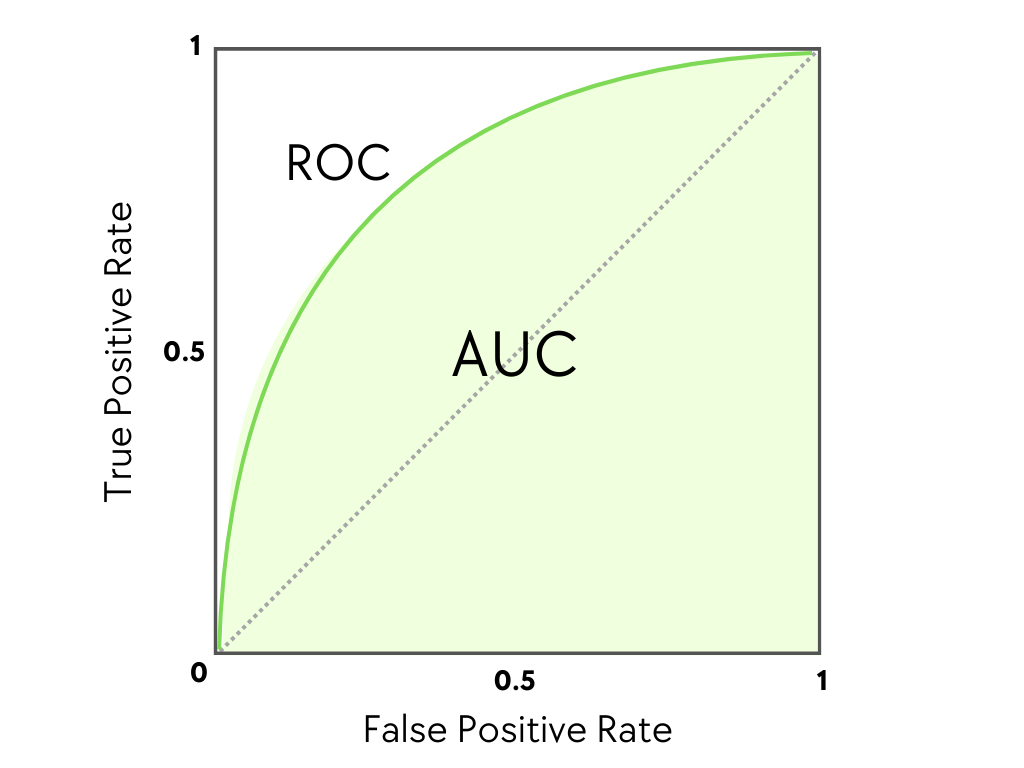
---

### Summary Table

| Metric         | Type          | Best Use Case                             |
|----------------|---------------|-------------------------------------------|
| MSE / RMSE     | Regression    | Measuring prediction error magnitude      |
| Accuracy       | Classification| Balanced datasets                         |
| Precision      | Classification| When false positives are costly           |
| Recall         | Classification| When false negatives are costly           |
| F1 Score       | Classification| When both precision and recall are important |
| AUC            | Classification| Evaluating model's ability to distinguish classes |


In [11]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Example actual and predicted values
y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.0, 8.0])

# Calculate MSE and RMSE
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Squared Error (MSE): 0.38
Root Mean Squared Error (RMSE): 0.61


Accuracy: 0.75
Precision: 0.75
Recall: 0.75
F1 Score: 0.75
ROC AUC: 0.94
Confusion Matrix:
[[3 1]
 [1 3]]


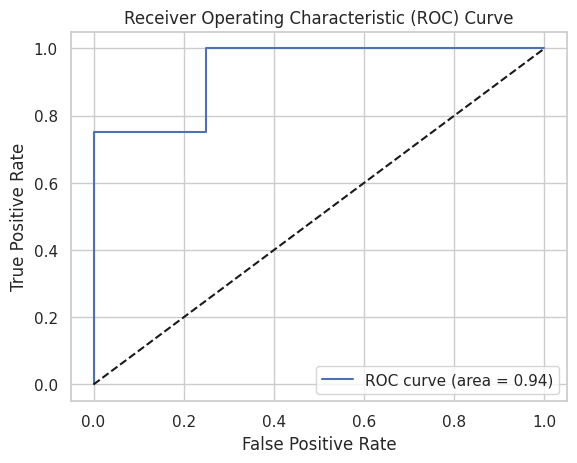

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Example actual and predicted values
y_true = [0, 1, 1, 0, 1, 0, 1, 0]
y_pred = [0, 1, 1, 0, 0, 1, 1, 0]
y_scores = [0.1, 0.9, 0.8, 0.2, 0.4, 0.6, 0.85, 0.05]  # Probabilities for ROC AUC

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_scores)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")
print("Confusion Matrix:")
print(conf_matrix)

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## Section 3: Logistic Regression

Logistic regression is a classification algorithm used when the target variable is **binary** (e.g., 0/1, yes/no, spam/not spam).

Unlike linear regression, which predicts continuous values, **logistic regression outputs probabilities**.

---

### 3.1 The Logistic Function

The model uses the **sigmoid function** to squash the output of a linear equation into a probability between 0 and 1:

$$
\hat{y} = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots)}}
$$

- If $\hat{y} \geq \text{threshold}$ → predict class 1
- Otherwise → predict class 0

The default threshold is 0.5, but this can be adjusted based on the problem.

---

### 3.2 Example: Logistic Regression on Synthetic Data

We’ll now fit a logistic regression model to a binary classification problem and evaluate it using the metrics we introduced earlier.


In [13]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Generate a synthetic dataset
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, random_state=1, class_sep=1.5)

# Fit logistic regression
clf = LogisticRegression()
clf.fit(X, y)

# Predict labels and probabilities
y_pred = clf.predict(X)
y_proba = clf.predict_proba(X)[:, 1]  # Probability of class 1


In [14]:
# Evaluation metrics
print("Classification Report:")
print(classification_report(y, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.94        98
           1       0.94      0.95      0.95       102

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200

Confusion Matrix:
[[92  6]
 [ 5 97]]


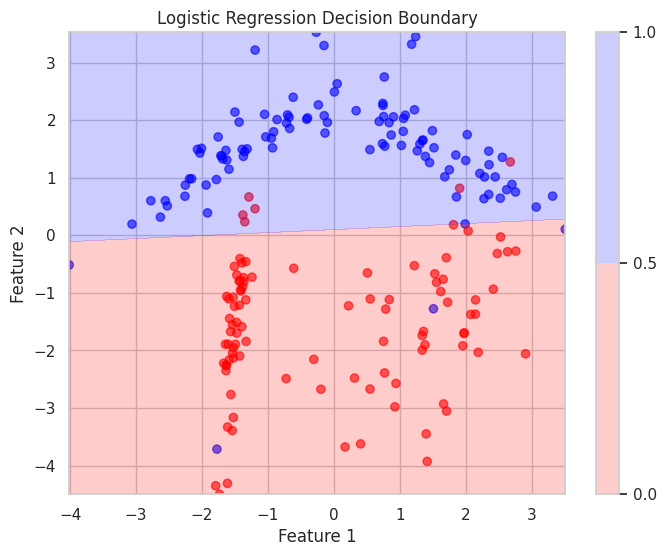

In [15]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
colors = ['red' if label == 0 else 'blue' for label in y]
plt.scatter(X[:, 0], X[:, 1], c=colors, alpha=0.6, label='Data')

# Create grid
xx, yy = np.meshgrid(np.linspace(X[:,0].min(), X[:,0].max(), 200),
                     np.linspace(X[:,1].min(), X[:,1].max(), 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot contour
contour = plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, colors=['red', 'blue'])
plt.colorbar(contour)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


### Summary

- Logistic regression models the **probability** that a sample belongs to class 1.
- It uses the **sigmoid function** to convert a linear model output into a probability between 0 and 1.
- By default, the **threshold** is 0.5, but it can be adjusted.
- We evaluate logistic regression using **classification metrics** like accuracy, precision, recall, F1 score, and AUC.

This wraps up the main content of our recitation.
Next, we will provide a final summary of everything we covered.
